In [1]:
from trot.config import configure_once
configure_once()

In [ ]:
import jax.numpy as jnp
import numpy as np

L = 4
U = 8.0
t = 1.0
N = L**2
h1 = np.zeros((N, N))
n_elec = (7,7)
for y in range(L):
    for x in range(L):
        site = y * L + x
        if x + 1 < L:
            h1[site, site + 1] = h1[site + 1, site] = -t
        if y + 1 < L:
            h1[site, site + L] = h1[site + L, site] = -t

_,orbitals = np.linalg.eig(h1)


In [ ]:
from trot.trial.ghf import GhfTrial
from trot.core.system import System
from trot.prop.cpmc_slow import make_prop_ops
from trot.meas.ghf import make_ghf_meas_ops_hubbard
from trot.trial.ghf import make_ghf_trial_ops
from trot.ham.hubbard import HamHubbard
from trot.driver import run_qmc
from trot.prop import blocks
from trot.prop.types import QmcParams

sys = System(N,n_elec,'unrestricted')
ham = HamHubbard(h1,U)

params = QmcParams(
    n_blocks=500,
    n_walkers=500,
    seed=23,
    n_eql_blocks=50
)
C = orbitals[:, :n_elec[0]].real
trial_data = np.block([[C, np.zeros((N, n_elec[1]))], [
                        np.zeros((N, n_elec[1])), C]])
trial = GhfTrial(jnp.asarray(trial_data))

meas_ops = make_ghf_meas_ops_hubbard(sys)
trial_ops = make_ghf_trial_ops(sys)
prop_ops = make_prop_ops(ham, 'unrestricted')
prop_ctx = prop_ops.build_prop_ctx(ham, None, params)

run = run_qmc(
    sys=sys,
    params=params,
    ham_data=ham,
    trial_data=trial,
    trial_ops=trial_ops,
    meas_ops=meas_ops,
    prop_ops=prop_ops,
    prop_ctx=prop_ctx,
    block_fn=blocks.block,
)

[chunks] automatic selection unavailable: the backend did not report a device memory limit; using n_chunks=1.

Equilibration:

        block           E_blk             W        nodes      t[s]
[eql    0/50]   20.3678640450  5.000000e+02           0       0.0
[eql   10/50]   17.0304170703  1.539474e+03         231      14.0


In [ ]:
import numpy as np
from pyscf import ao2mo, gto, scf

L, U, t = 4, 8.0, 1.0
N = L * L
n_up = n_dn = N // 2 - 1

h1 = np.zeros((N, N))
for y in range(L):
    for x in range(L):
        site = y * L + x
        if x + 1 < L:
            h1[site, site + 1] = h1[site + 1, site] = -t
        if y + 1 < L:
            h1[site, site + L] = h1[site + L, site] = -t

n_tries = 1000
seeds = np.arange(n_tries)
one_rdms = np.zeros((n_tries,2,N,N))
Cas = np.zeros((n_tries,N,n_up))
Cbs = np.zeros((n_tries,N,n_up))
energies = np.zeros(n_tries)
guesses = np.zeros((n_tries,2,N,N))
for k,seed in enumerate(seeds):
    np.random.seed(seed)
    guess = np.random.rand(2, N, N)  # diagonal density matrices of the product state
    guesses[k] = guess
    eri = np.zeros((N,) * 4)
    for i in range(N):
        eri[i, i, i, i] = U
    mol = gto.M(verbose=0)
    mol.incore_anyway = True
    mol.nelec = (n_up, n_dn)
    mf = scf.UHF(mol)
    mf.get_hcore = lambda *args: h1
    mf.get_ovlp = lambda *args: np.eye(N)
    mf._eri = ao2mo.restore(8, eri, N)
    mf.kernel(guess)
    mo1 = mf.stability()[0]
    dm1 = mf.make_rdm1(mo1, mf.mo_occ)
    mf = mf.run(dm1)
    mf.stability()
    Ca, Cb = mf.mo_coeff[0][:, :n_up], mf.mo_coeff[1][:, :n_dn]
    Cas[k] = Ca
    Cbs[k] = Cb
    rdm_up, rdm_dn = (np.diag(dm) for dm in mf.make_rdm1())
    one_rdm =  mf.make_rdm1()
    one_rdms[k] = one_rdm.copy()
    energies[k] = mf.e_tot
    

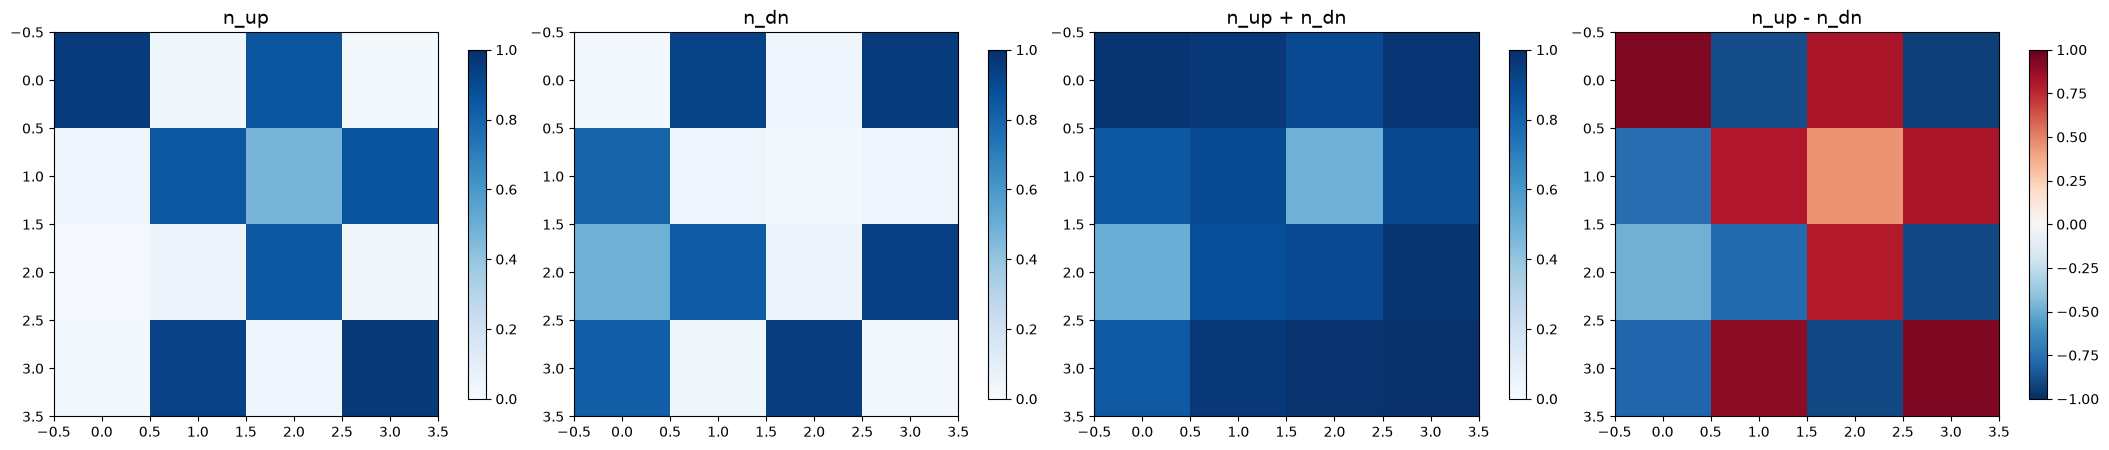

seed 617, E_UHF = -7.72194226


In [ ]:
import matplotlib.pyplot as plt

def occupation_plot(rdm1):
    """n_up, n_dn, density, magnetization and staggered magnetization on the lattice, saved to path."""
    n_up_site, n_dn_site = (np.diag(rdm1[s]).reshape(L, L) for s in (0, 1))
    sign = (-1.0) ** np.add.outer(np.arange(L), np.arange(L))  # (-1)^(x+y), indexed [y, x]
    density = n_up_site + n_dn_site
    panels = [(n_up_site, "n_up", "Blues", 0.0, 1.0),
              (n_dn_site, "n_dn", "Blues", 0.0, 1.0),
              (density, "n_up + n_dn", "Blues", 0.0, max(1.0, density.max())),
              (n_up_site - n_dn_site, "n_up - n_dn", "RdBu_r", -1.0, 1.0),]
    fig, axes = plt.subplots(1, len(panels), figsize=(21, 4.6), layout="constrained")
    for ax, (values, name, cmap, vmin, vmax) in zip(axes, panels):
        image = ax.imshow(values, cmap=cmap, vmin=vmin, vmax=vmax)
        ax.set_title(name, fontsize=14)
        fig.colorbar(image, ax=ax, shrink=0.8)
    plt.show()

k = np.argmin(energies)
seed = int(seeds[k])
np.random.seed(seed)
occupation_plot(one_rdms[k])
print(f"seed {seed}, E_UHF = {energies[k]:.8f}")


In [ ]:
i = np.argmin(energies)
Ca, Cb = Cas[i], Cbs[i]

trial_data = np.block([
    [Ca[:, :n_elec[0]],  Cb[:, :n_elec[1]]],
    [Ca[:, :n_elec[0]], -Cb[:, :n_elec[1]]],
])  
trial = GhfTrial(jnp.array(trial_data))

run = run_qmc(
    sys=sys,
    params=params,
    ham_data=ham,
    trial_data=trial,
    trial_ops=trial_ops,
    meas_ops=meas_ops,
    prop_ops=prop_ops,
    prop_ctx=prop_ctx,
    block_fn=blocks.block,
)

[chunks] automatic selection unavailable: the backend did not report a device memory limit; using n_chunks=1.

Equilibration:

        block           E_blk             W        nodes      t[s]
[eql    0/50]   -8.7018559702  5.000000e+02           0       0.0
[eql   10/50]   -9.5647734966  5.141480e+02          56      14.5
[eql   20/50]   -9.4730506835  5.037199e+02         142      29.7
[eql   30/50]   -9.4919291971  5.020383e+02         216      43.8
[eql   40/50]   -9.4626107876  5.018143e+02         315      57.8
[eql   50/50]   -9.5380158192  5.012047e+02         400      72.6

Sampling:

        block           E_avg       E_err         E_block             W         nodes    dt[s/bl]     t[s]
[blk   50/500]   -9.4645053143   1.223e-02     -9.4645053143  5.003694e+02         834      1.442     144.7
[blk  100/500]   -9.4589135991   8.779e-03     -9.4533264276  5.007763e+02        1301      1.370     213.2
[blk  150/500]   -9.4509439516   7.443e-03     -9.4350108079  5.007661e+02 